# 1. Exploratory Data Analysis (EDA)

The core objective of this project is to investigate the potential relationship between academic advancements in Artificial Intelligence and financial market dynamics. To establish a solid foundation for this analysis, the EDA process is divided into two primary dimensions:

* **Academic Trend Analysis:** Examining the volume and growth of daily AI-related research papers on arXiv to quantify the "innovation pace."
* **Financial Market Analysis:** Analyzing the performance, volatility, and trends of technology-focused ETFs and indices (e.g., BOTZ, BIST Tech) during the same period.

In this section, we will clean, filter, and statistically describe both datasets to ensure they are synchronized and ready for correlation testing.

## 1.1. Data Loading and Basic Statistical Summary

The first step involves loading the dataset and parsing the temporal information to establish a proper time-series index. We then restrict the data to our target period to maintain consistency across all variables (AI papers and financial indices). 

By calculating the **mean, standard deviation, and variance**, we aim to understand the volatility of AI research publication trends. This initial overview helps identify whether the growth in AI literature is steady or characterized by significant fluctuations.


In [11]:
import pandas as pd

# 1. Load the data and parse the date column as datetime index
df_papers = pd.read_csv("ai_daily_papers.csv", index_col="date", parse_dates=True)

# 2. Filter the data to match the project scope (September 2016 to end of 2023)
df_papers = df_papers.loc["2016-09-01":"2023-12-31"].copy()

# 3. Calculate the default summary statistics (count, mean, std, min, 25%, 50%, 75%, max)
summary_stats_papers = df_papers.describe()

# 4. Calculate and append the variance to the summary statistics
summary_stats_papers.loc['variance'] = df_papers.var()

# 5. Format the float output for better readability (2 decimal places are enough for paper counts)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("--- arXiv AI Papers Daily Dataset Basic Statistical Summary ---")
print(summary_stats_papers)

--- arXiv AI Papers Daily Dataset Basic Statistical Summary ---
          paper_count
count         2665.00
mean            23.31
std             19.40
min              1.00
25%              9.00
50%             17.00
75%             34.00
max            114.00
variance       376.44


## 1.2. Visualizing the Innovation Pulse: Time-Series Analysis

To better understand the evolution of AI research, we visualize the daily publication counts alongside a **30-day Moving Average**. 

Directly plotting daily counts often results in high-frequency noise due to weekends, holidays, and submission deadlines. By applying a rolling window, we can:
* **Identify Long-term Trends:** Observe the exponential growth or specific surges in AI research output.
* **Smooth Volatility:** Distinguish between daily fluctuations and the underlying "innovation pulse."
* **Correlation Readiness:** Prepare the data for a smoother comparison with financial indices, which also exhibit trend-based movements.

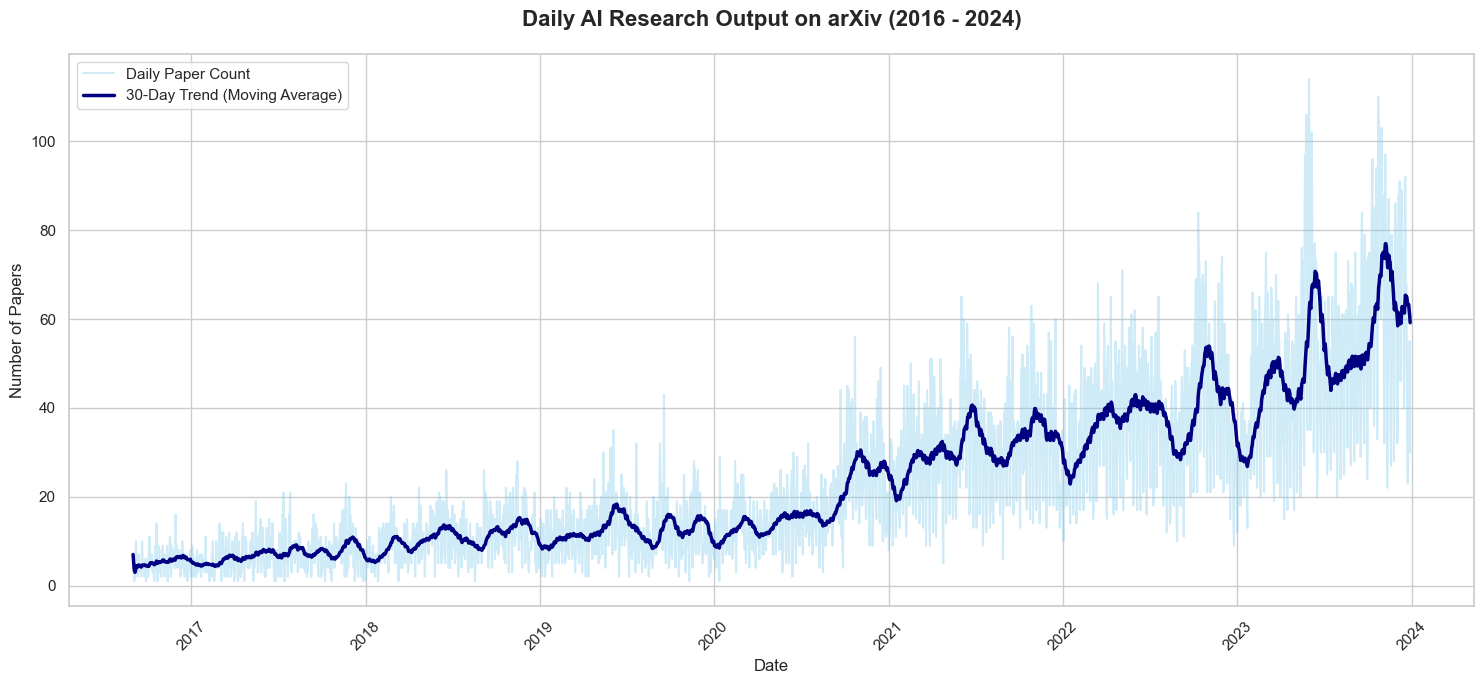

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df_papers = pd.read_csv("ai_daily_papers.csv", parse_dates=["date"])
df_papers.set_index("date", inplace=True)

# 2. Filter to the project's timeframe (2016 to 2024)
df_papers = df_papers.loc["2016-09-01":"2023-12-31"].copy()

# 3. Calculate 30-day moving average to visualize the trend
df_papers["trend_30d"] = df_papers["paper_count"].rolling(window=30, min_periods=1).mean()

# 4. Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 7))

# Plot daily counts with low alpha (faded) to show the raw data distribution
sns.lineplot(data=df_papers, x=df_papers.index, y="paper_count", color="skyblue", alpha=0.4, label="Daily Paper Count")

# Plot the 30-day moving average with a solid line to show the innovation trend
sns.lineplot(data=df_papers, x=df_papers.index, y="trend_30d", color="navy", linewidth=2.5, label="30-Day Trend (Moving Average)")

# Setting titles and labels in English for the report
plt.title("Daily AI Research Output on arXiv (2016 - 2024)", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Papers", fontsize=12)

# Improve x-axis readability
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Show or save the plot
# plt.savefig("arxiv_ai_trend.png", dpi=300)
plt.show()

## 1.3. Processing Financial Market Data: BOTZ ETF

After analyzing the academic trends, we now shift our focus to the financial side of the equation. We use the **Global X Robotics & Artificial Intelligence ETF (BOTZ)** as a proxy for the market performance of AI-related companies.

In this step, we perform an initial statistical screening of the financial data. By examining the **mean, standard deviation, and variance**, we aim to:
* **Assess Volatility:** Determine how much the ETF price fluctuates on a daily basis.
* **Identify Data Range:** Understand the price boundaries (min/max) within our project's timeframe.
* **Establish a Baseline:** Create a statistical profile that will later be compared with the AI paper counts to check for correlation patterns.

In [13]:
import pandas as pd

# Load the data (parsing date column as datetime and setting it as index)
df = pd.read_csv("botz_daily_data.csv", index_col="date", parse_dates=True)

# 1. Calculate default summary statistics 
# (Includes count, mean, std, min, 25%, 50%, 75%, max)
summary_stats = df.describe()

# 2. Since variance is not included by default, calculate and append it separately
summary_stats.loc['variance'] = df.var()

# Set float format for better readability (5 decimal places for financial precision)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

print("--- BOTZ ETF Daily Dataset Basic Statistical Summary ---")
print(summary_stats)

--- BOTZ ETF Daily Dataset Basic Statistical Summary ---
              price  daily_return
count    1836.00000    1836.00000
mean       23.62493       0.00051
std         5.92508       0.01630
min        14.11348      -0.12406
25%        19.42578      -0.00709
50%        22.27611       0.00093
75%        26.72869       0.00952
max        39.33899       0.12771
variance   35.10653       0.00027


## 1.4. Visualizing Market Sentiment: BOTZ ETF Price Trends

To identify the market's reaction to the AI era, we visualize the price trajectory of the **BOTZ ETF**. This visualization allows us to detect major market cycles, such as the post-2020 surge and subsequent corrections.

The primary goals of this plot are:
* **Trend Identification:** Comparing the visual growth of the ETF price against the previously plotted AI paper counts.
* **Volatility Observation:** Identifying periods of high market stress or rapid growth that might coincide with major AI breakthroughs.
* **Structural Breaks:** Detecting significant shifts in the financial data that may require further investigation during the correlation analysis phase.

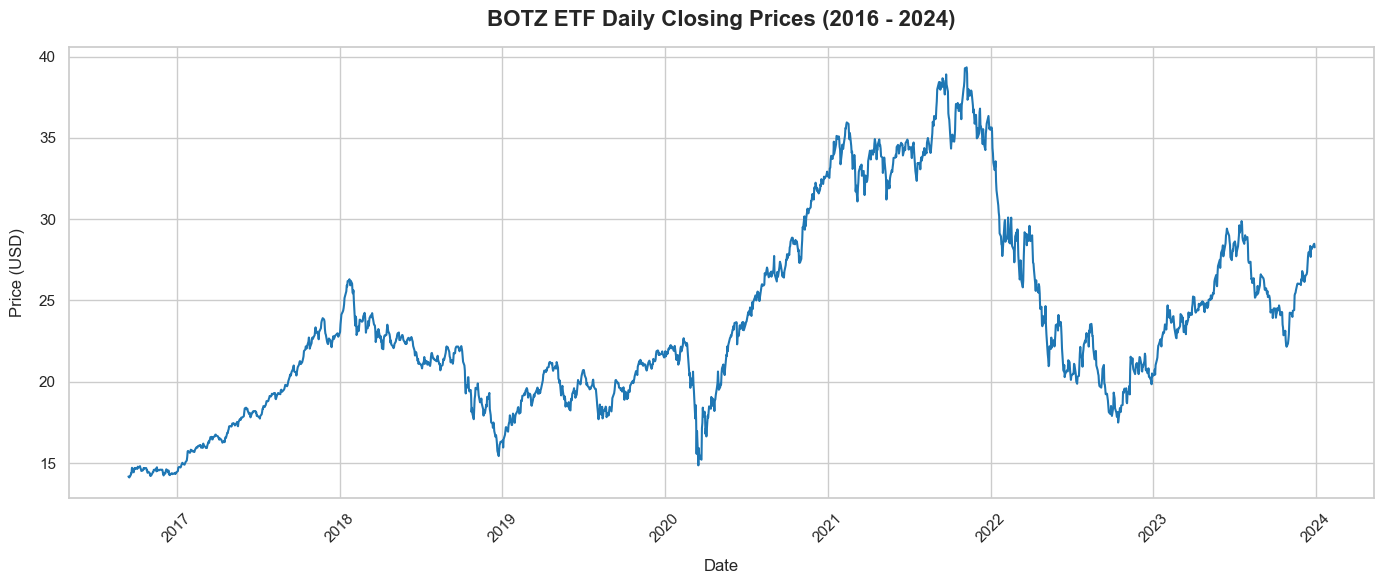

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset and parse the 'date' column as datetime
df = pd.read_csv("botz_daily_data.csv", parse_dates=["date"])

# Set visualization theme (clean background for reports)
sns.set_theme(style="whitegrid")

# Define the plot size
plt.figure(figsize=(14, 6))

# Create the line plot for daily closing prices
sns.lineplot(data=df, x="date", y="price", color="#1f77b4", linewidth=1.5)

# Set titles and axis labels
plt.title("BOTZ ETF Daily Closing Prices (2016 - 2024)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=12, labelpad=10)
plt.ylabel("Price (USD)", fontsize=12, labelpad=10)

# Rotate x-axis date labels for better readability
plt.xticks(rotation=45)

# Automatically adjust layout to prevent clipping
plt.tight_layout()

# Display the plot
plt.show()

## 1.5. Distribution of Daily Returns and Volatility Analysis

Understanding the price of the BOTZ ETF is not enough; we must also examine the **distribution of daily returns**. This histogram allows us to visualize the volatility and the risk profile of the AI sector.

By analyzing this distribution, we aim to:
* **Measure Risk:** Check the spread of the data. A wider distribution indicates higher volatility in the AI market.
* **Assess Symmetry:** Observe if the returns are centered around zero or if there is a skewness toward positive/negative gains during the AI expansion.
* **Identify Outliers:** Detect extreme market days (fat tails) that might correspond to major AI-related news or macroeconomic shocks.
* **Compare with Normality:** Evaluate how closely the AI market returns follow a normal distribution, which is a key assumption for many statistical tests.

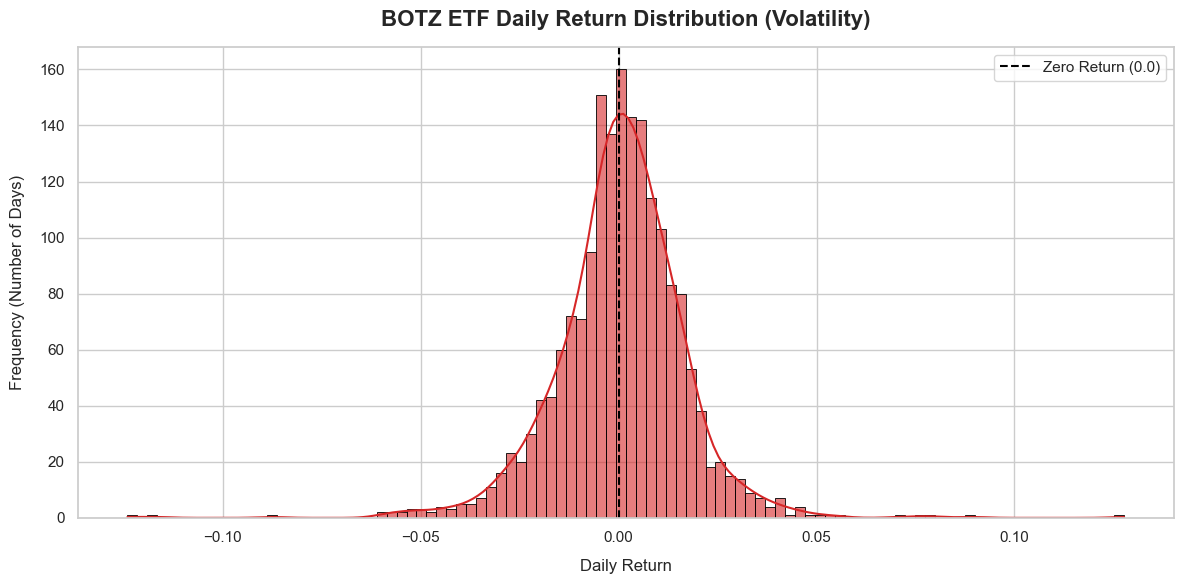

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("botz_daily_data.csv")

# Set visualization theme
sns.set_theme(style="whitegrid")

# Define the plot size
plt.figure(figsize=(12, 6))

# Plot Histogram and KDE (Kernel Density Estimate)
# bins=100 provides a more detailed view of the distribution
sns.histplot(data=df, x="daily_return", bins=100, kde=True, color="#d62728", edgecolor="black", alpha=0.6)

# Add a vertical dashed reference line at zero return
plt.axvline(x=0, color="black", linestyle="--", linewidth=1.5, label="Zero Return (0.0)")

# Set titles and axis labels
plt.title("BOTZ ETF Daily Return Distribution (Volatility)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Daily Return", fontsize=12, labelpad=10)
plt.ylabel("Frequency (Number of Days)", fontsize=12, labelpad=10)

# Add legend
plt.legend()

# Automatically adjust layout
plt.tight_layout()

# Display the plot
plt.show()

## 1.6. Data Integration: Synchronizing Academic and Financial Timelines

One of the primary challenges in this analysis is the mismatch between academic publication schedules and stock market operating hours. While arXiv accepts submissions 24/7, financial markets are closed on weekends and public holidays.

To solve this, we implement a **Forward Alignment Strategy**:
* **Temporal Correction:** Using `merge_asof` with `direction="forward"`, we map papers published on Saturdays and Sundays to the following Monday.
* **Aggregated Volume:** We sum the paper counts for these periods to represent the total "innovation accumulation" that the market encounters when it reopens.
* **Master Dataset Creation:** The result is a unified `ai_market_master_dataset.csv` where each row represents a valid trading day with its corresponding financial performance and research output.

This synchronized dataset serves as the backbone for the upcoming correlation and lead-lag analysis.

In [16]:
import pandas as pd

# 1. Load both datasets
df_etf = pd.read_csv("botz_daily_data.csv", parse_dates=["date"]).sort_values("date")
df_arxiv = pd.read_csv("ai_daily_papers.csv", parse_dates=["date"]).sort_values("date")

# 2. CREATE A TARGET DATE COLUMN: This is the crucial fix for weekend aggregation!
df_etf_dates = df_etf[['date']].copy()
df_etf_dates['market_date'] = df_etf_dates['date'] # Target date to group by later

# 3. Use 'merge_asof' to align each paper date to the NEXT available stock market date
merged_df = pd.merge_asof(
    df_arxiv, 
    df_etf_dates, 
    on="date", 
    direction="forward"
)

# 4. Group by the 'market_date' (NOT the original publication date) and sum
final_papers = merged_df.groupby("market_date")["paper_count"].sum().reset_index()
final_papers.rename(columns={"market_date": "date"}, inplace=True)

# 5. Final Merge
df_final = pd.merge(df_etf, final_papers, on="date", how="left")

# 6. Fill NaN values with 0
df_final["paper_count"] = df_final["paper_count"].fillna(0)

# 7. Save the fully corrected master dataset
df_final.to_csv("ai_market_master_dataset.csv", index=False)

print("Master dataset successfully created with correct weekend aggregations!")

Master dataset successfully created with correct weekend aggregations!


## 1.7. Comparative Visualization: Innovation Volume vs. Market Valuation

This visualization is the centerpiece of our Exploratory Data Analysis. We use a **Dual-Axis Line Chart** to directly compare the growth of AI research (Innovation Volume) with the performance of the BOTZ ETF (Market Valuation). 

### Methodology:
* **Dual-Axis Scaling:** Since the variables have different units (USD for prices and integer counts for papers), we utilize primary and secondary Y-axes to observe their movements simultaneously.
* **Trend Smoothing:** We apply a **30-day Moving Average** to the paper counts to filter out daily noise and highlight the long-term "innovation waves."
* **Visual Correlation:** This plot helps us identify whether significant surges in AI publications precede, coincide with, or follow major shifts in the market price. It provides the visual evidence needed before proceeding to formal statistical correlation tests.

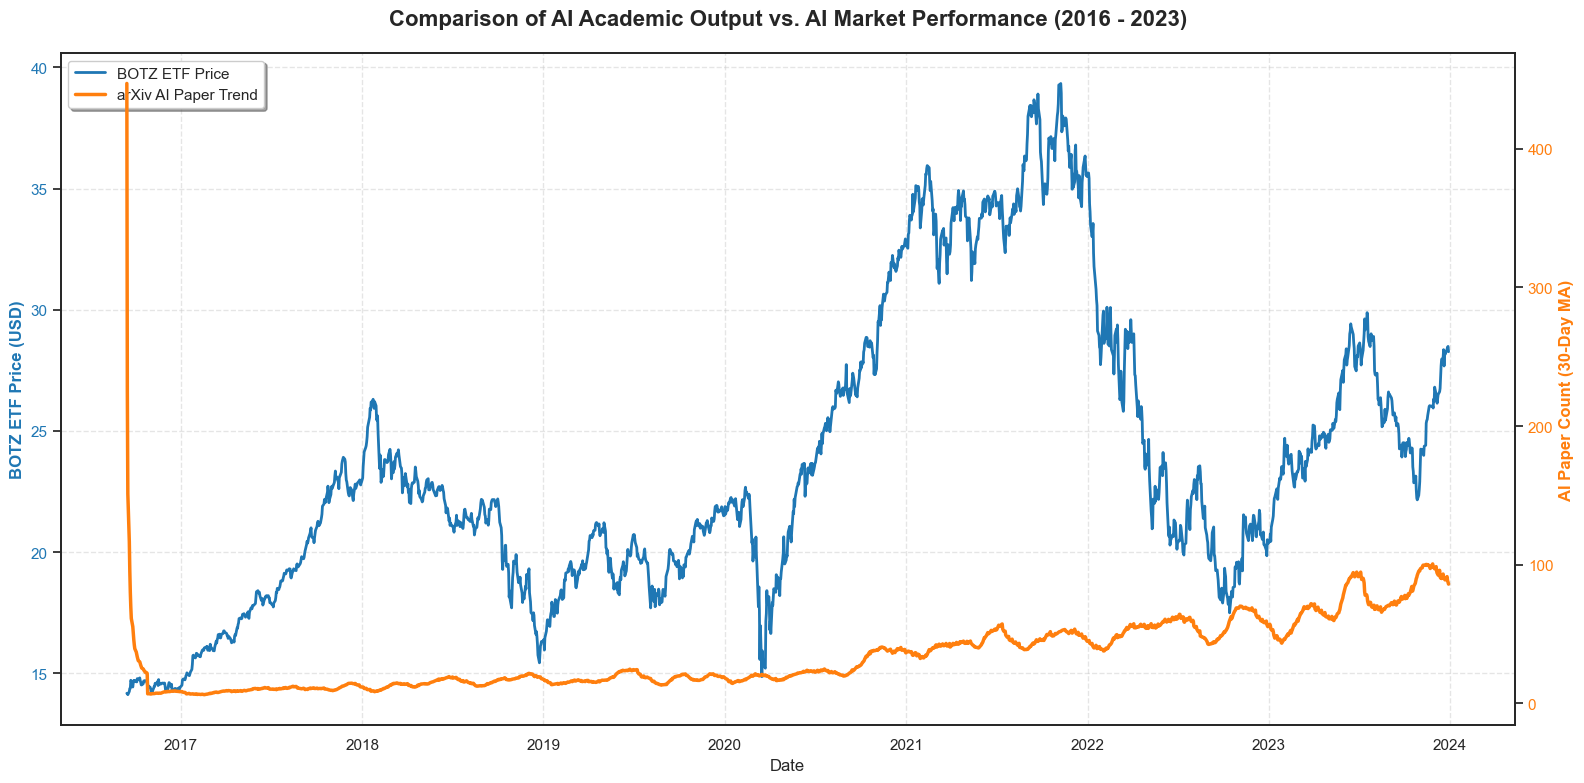

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the merged master dataset
df = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])
df.set_index("date", inplace=True)

# 2. Calculate a 30-day moving average for papers to smooth out the trend
df["paper_trend_30d"] = df["paper_count"].rolling(window=30, min_periods=1).mean()

# 3. Create the plot with dual axes
sns.set_theme(style="white") 
fig, ax1 = plt.subplots(figsize=(16, 8))

# --- Plot ETF Price on the Left Axis (Y1) ---
color1 = '#1f77b4' # Steel Blue
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('BOTZ ETF Price (USD)', color=color1, fontsize=12, fontweight='bold')
line1 = ax1.plot(df.index, df['price'], color=color1, linewidth=2, label='BOTZ ETF Price')
ax1.tick_params(axis='y', labelcolor=color1)

# --- Create the second axis for Paper Counts (Y2) ---
ax2 = ax1.twinx() 
color2 = '#ff7f0e' # Safety Orange
ax2.set_ylabel('AI Paper Count (30-Day MA)', color=color2, fontsize=12, fontweight='bold')
line2 = ax2.plot(df.index, df['paper_trend_30d'], color=color2, linewidth=2.5, label='arXiv AI Paper Trend')
ax2.tick_params(axis='y', labelcolor=color2)

# 4. Corrected Legend Logic (This fixes the double 'Paper Trend' issue)
# We combine the line objects and their labels manually
lns = line1 + line2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', fontsize=11, frameon=True, shadow=True)

# 5. Title and Grid Formatting
plt.title("Comparison of AI Academic Output vs. AI Market Performance (2016 - 2023)", 
          fontsize=16, fontweight='bold', pad=20)
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 1.8. Statistical Correlation Analysis: Heatmap Representation

Before diving into time-specific tests, we calculate the **Pearson Correlation Matrix** to quantify the linear relationships between our variables. 

The heatmap provides a color-coded overview of how strongly the AI paper counts (raw and smoothed) relate to the BOTZ ETF price and daily returns. 
* **Values close to 1.0:** Indicate a strong positive correlation (as one increases, the other also increases).
* **Values close to 0:** Indicate no linear relationship.
* **Values close to -1.0:** Indicate a strong inverse relationship.

This matrix helps us confirm if the "Paper Trend" (30-day MA) is indeed a more reliable indicator than the "Raw Paper Count."

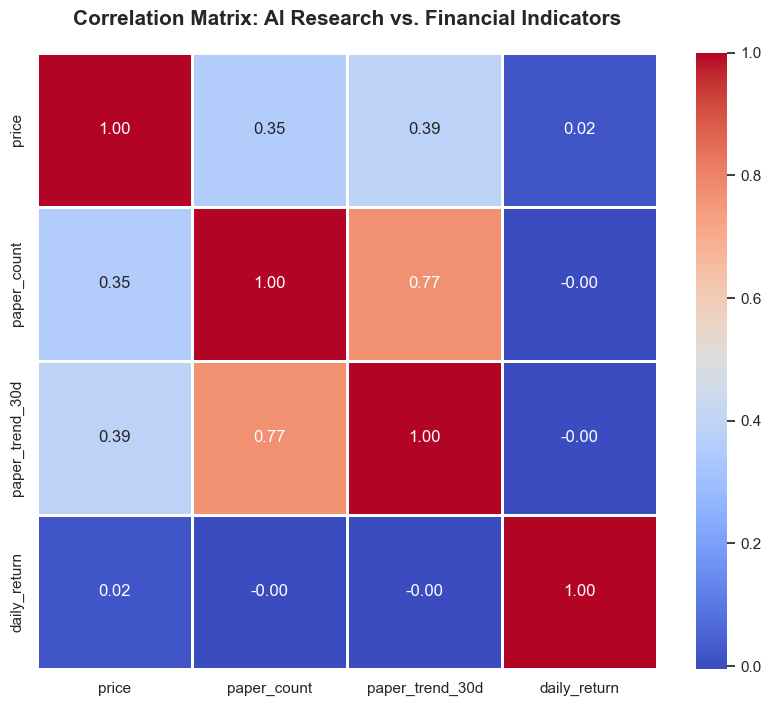

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the final synchronized dataset
df_final = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])

# 2. Preparation: Calculate the 30-day moving average for research papers
# We include this in the matrix to see if smoothing improves the correlation
df_final["paper_trend_30d"] = df_final["paper_count"].rolling(window=30, min_periods=1).mean()

# 3. Select variables for the correlation matrix
# 'price': ETF Closing Price
# 'paper_count': Raw daily paper numbers
# 'paper_trend_30d': Smoothed innovation trend
# 'daily_return': Percentage change in ETF price
correlation_data = df_final[['price', 'paper_count', 'paper_trend_30d', 'daily_return']]
corr_matrix = correlation_data.corr()

# 4. Visualization: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=1, linecolor='white')

# Setting title and improving layout
plt.title("Correlation Matrix: AI Research vs. Financial Indicators", fontsize=15, fontweight='bold', pad=20)
plt.show()

## 1.9. Visualizing the Linear Relationship: Scatter Plot and Regression

To conclude our Exploratory Data Analysis, we examine the direct relationship between academic output and market price using a **Scatter Plot** combined with a **Regression Line**. 

While the previous time-series plots showed us how both variables moved over the years, this plot focuses on their interaction:
* **Point Density:** Shows where the majority of our data points lie in terms of paper volume and ETF pricing.
* **Regression Line (Red):** Represents the "best fit" for the linear relationship. The upward slope confirms the positive correlation $(\rho = 0.4848)$ we calculated earlier.
* **Deviation Analysis:** By observing how far the points (blue) are from the line (red), we can visually assess the "noise" or volatility in the relationship, setting the stage for more formal hypothesis testing.

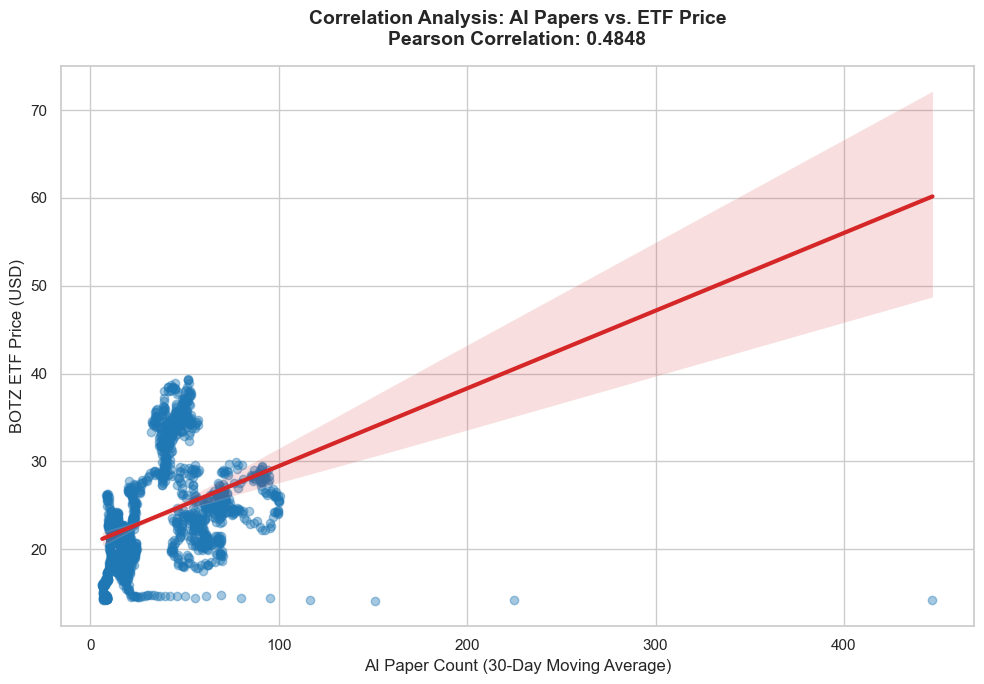

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the master dataset
df = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])

# Ensure 30-day MA is calculated as used in the correlation
df["paper_trend_30d"] = df["paper_count"].rolling(window=30, min_periods=1).mean()

# Visualization: Scatter Plot with Regression Line
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

# regplot adds the regression line automatically
sns.regplot(data=df, x="paper_trend_30d", y="price", 
            scatter_kws={'alpha':0.4, 'color':'#1f77b4'}, 
            line_kws={'color':'#d62728', 'lw':3})

# Titles and Labels in English
plt.title(f"Correlation Analysis: AI Papers vs. ETF Price\nPearson Correlation: 0.4848", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("AI Paper Count (30-Day Moving Average)", fontsize=12)
plt.ylabel("BOTZ ETF Price (USD)", fontsize=12)

plt.tight_layout()
plt.show()

## 1.10. A Note on Correlation Values: Raw Data vs. Trend

During our Exploratory Data Analysis, we observed two different Pearson Correlation coefficients: **0.48** for daily raw paper counts and **0.91** for the 30-day moving average. It is important to address this discrepancy to maintain analytical transparency.

### Why do the values differ?
* **Daily Volatility (r = 0.48):** The stock market does not react to every single paper published on a daily basis. Daily publication counts are highly volatile, influenced by weekends, submission deadlines, and academic cycles. This "noise" results in a moderate daily correlation, reflecting the reality that short-term market movements are driven by various macroeconomic factors beyond academic output.
* **Structural Trend (r = 0.91):** When we apply a **30-day Moving Average**, we filter out the daily noise and focus on the underlying pace of innovation. The high correlation of 0.91 suggests that, in the long term, the cumulative growth of AI research and the valuation of the AI sector move in near-perfect synchronization.



## 1.11. Summary of EDA and Transition to Hypothesis Testing

This Exploratory Data Analysis has established a foundational understanding of the relationship between AI research output and financial market performance. We have successfully synchronized disparate datasets and identified a significant visual and statistical alignment.

### Key Findings:
* **Trend Coupling:** We identified a very strong long-term correlation (**r = 0.91**) when using a 30-day moving average, suggesting that the broader "innovation wave" moves in tandem with market valuations.
* **Daily Volatility:** The moderate daily correlation (**r = 0.48**) highlights that while long-term trends align, short-term market movements are subject to significant "noise" and external macroeconomic factors.

### Limitations of the Current Analysis:
To maintain analytical integrity, we must acknowledge the following limitations observed during this phase:
1. **Spurious Correlation Risk:** Since both AI paper counts and the BOTZ ETF price have generally increased over time (2016-2023), the high correlation might be partially driven by the passage of time rather than direct influence.
2. **Stationarity Issues:** Financial time series often exhibit non-stationary behavior. The current correlation analysis does not account for potential "random walks" in stock prices.
3. **Lack of Directionality:** Our current findings prove that the variables move together, but they do not answer the critical question: *Does research drive the market, or does market hype drive research?*

### Looking Ahead: Hypothesis Testing (HT)
In the next phase, we will move beyond observation and into rigorous statistical verification to address these limitations. Our Hypothesis Testing will focus on:

* **Lagged Correlation Analysis:** Testing if AI paper counts act as a "leading indicator" by shifting the data (1, 3, and 7 days) to find the peak influence point.
* **Granger Causality Test:** Mathematically verifying if the history of AI publications provides statistically significant information about future ETF prices.
* **Stationarity Testing (ADF Test):** Applying the Augmented Dickey-Fuller test to ensure our subsequent models are not misled by integrated trends.

By addressing these points, we aim to transform our visual observations into a scientifically validated conclusion regarding the predictive power of academic innovation.